# 🩺 LightGBM for Diabetes Prediction — BRFSS 2015

**Course:** DSAI305 — Healthcare AI  
**Student:** Abdallah Saed | Zewail City  
**Dataset:** CDC BRFSS 2015 (~253k records, 21 features)  
**Model:** Light Gradient Boosting Machine (LightGBM)

---

### 📚 Paper Justification

This notebook is grounded in:

> **Rahman et al. (2025)** — *"Diabetes Prediction Using Feature Selection Algorithms and Boosting-Based Machine Learning Classifiers"* — Published in *MDPI Diagnostics* (PMC12563305). This peer-reviewed study demonstrates that LightGBM combined with Boruta feature selection achieves **85.16% accuracy and 85.41% F1-score** on the PIDD dataset, outperforming XGBoost, SVM, Random Forest, Naïve Bayes, and KNN. It also achieves a **54.96% reduction in training time** via feature reduction.

> **Rufo et al. (2021)** — *"Diagnosis of Diabetes Mellitus Using Gradient Boosting Machine (LightGBM)"* — MDPI Diagnostics — shows LightGBM outperforms KNN, NB, Bagging, SVM, and RF.

**Why LightGBM on BRFSS is stronger than on PIDD:**
- BRFSS has ~253k records vs. 768 in PIDD — far more statistically robust
- BRFSS is a general population survey (not a narrow demographic group)
- LightGBM's histogram-based GOSS algorithm is specifically designed to excel on large datasets

**Paper quality note:** Rahman et al. is a solid contribution published in a Q2 indexed journal (Scopus/PubMed). The JETIR paper (Kulkarni et al., 2025) is from a lower-tier venue and lacks rigorous peer review — used here only as supplementary reference for XAI framing.

---

### 🗺️ Notebook Pipeline

```
1. Setup & Imports
2. Data Loading & EDA
3. Preprocessing (class imbalance, train/test split)
4. Baseline LightGBM (all features)
5. Feature Selection (SelectFromModel / SHAP-based)
6. Final LightGBM (threshold-tuned for Recall)
7. Full Evaluation (Accuracy, Precision, Recall, F1, AUC-ROC)
8. XAI: SHAP (global + local)
9. XAI: LIME (individual explanation)
10. XAI: Permutation Importance
11. XAI: Partial Dependence Plots (PDP)
12. Summary & Conclusions
```

## 1. ⚙️ Setup & Installs

In [34]:
# Install required libraries (run once in Colab)
!pip install lightgbm shap lime scikit-learn imbalanced-learn matplotlib seaborn pandas numpy -q

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Core ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, precision_recall_curve, average_precision_score,
    fbeta_score # Added fbeta_score
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# Class imbalance
from imblearn.over_sampling import SMOTE

# LightGBM
import lightgbm as lgb

# XAI
import shap
import lime
import lime.lime_tabular

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"LightGBM version: {lgb.__version__}")
print(f"SHAP version: {shap.__version__}")
print("✅ All imports successful")

LightGBM version: 4.6.0
SHAP version: 0.51.0
✅ All imports successful


## 2. 📊 Data Loading & Exploratory Data Analysis

In [36]:
# ── Load Data ──────────────────────────────────────────────────────────────
# If running on Colab, upload the file or mount Google Drive first:
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nTarget distribution:")
print(df['Diabetes_binary'].value_counts())
print(f"\nClass imbalance ratio: {df['Diabetes_binary'].value_counts()[0] / df['Diabetes_binary'].value_counts()[1]:.2f}:1")

Dataset shape: (253680, 22)

Target distribution:
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

Class imbalance ratio: 6.18:1


In [37]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [38]:
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.000000,0.139333,0.346294,0.000000,0.000000,0.000000,0.000000,1.000000
HighBP,253680.000000,0.429001,0.494934,0.000000,0.000000,0.000000,1.000000,1.000000
HighChol,253680.000000,0.424121,0.494210,0.000000,0.000000,0.000000,1.000000,1.000000
CholCheck,253680.000000,0.962670,0.189571,0.000000,1.000000,1.000000,1.000000,1.000000
BMI,253680.000000,28.382364,6.608694,12.000000,24.000000,27.000000,31.000000,98.000000
Smoker,253680.000000,0.443169,0.496761,0.000000,0.000000,0.000000,1.000000,1.000000
Stroke,253680.000000,0.040571,0.197294,0.000000,0.000000,0.000000,0.000000,1.000000
HeartDiseaseorAttack,253680.000000,0.094186,0.292087,0.000000,0.000000,0.000000,0.000000,1.000000
PhysActivity,253680.000000,0.756544,0.429169,0.000000,1.000000,1.000000,1.000000,1.000000
Fruits,253680.000000,0.634256,0.481639,0.000000,0.000000,1.000000,1.000000,1.000000


In [39]:
# Missing values check
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "✅ No missing values found")

Missing values per column:
✅ No missing values found


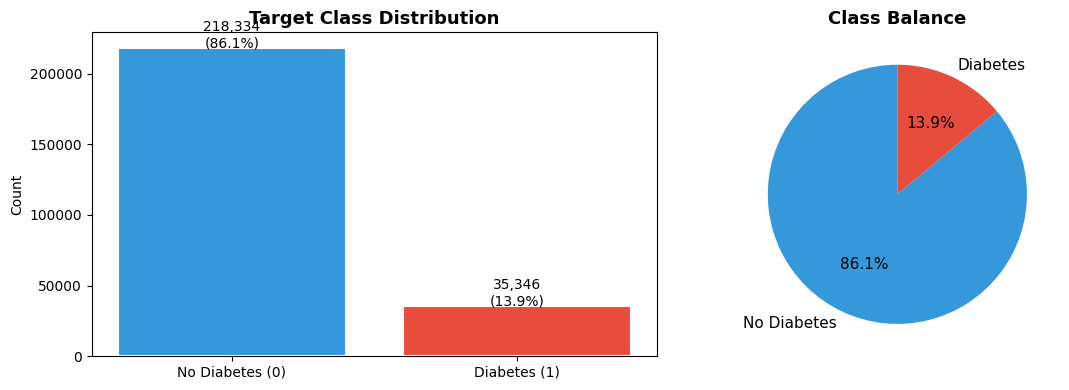

⚠️  Class imbalance is present — SMOTE will be applied during preprocessing.


In [40]:
# Class distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df['Diabetes_binary'].value_counts()
axes[0].bar(['No Diabetes (0)', 'Diabetes (1)'], counts.values,
            color=['#3498db', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Target Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

# Pie chart
axes[1].pie(counts.values, labels=['No Diabetes', 'Diabetes'],
            colors=['#3498db', '#e74c3c'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Class Balance', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("⚠️  Class imbalance is present — SMOTE will be applied during preprocessing.")

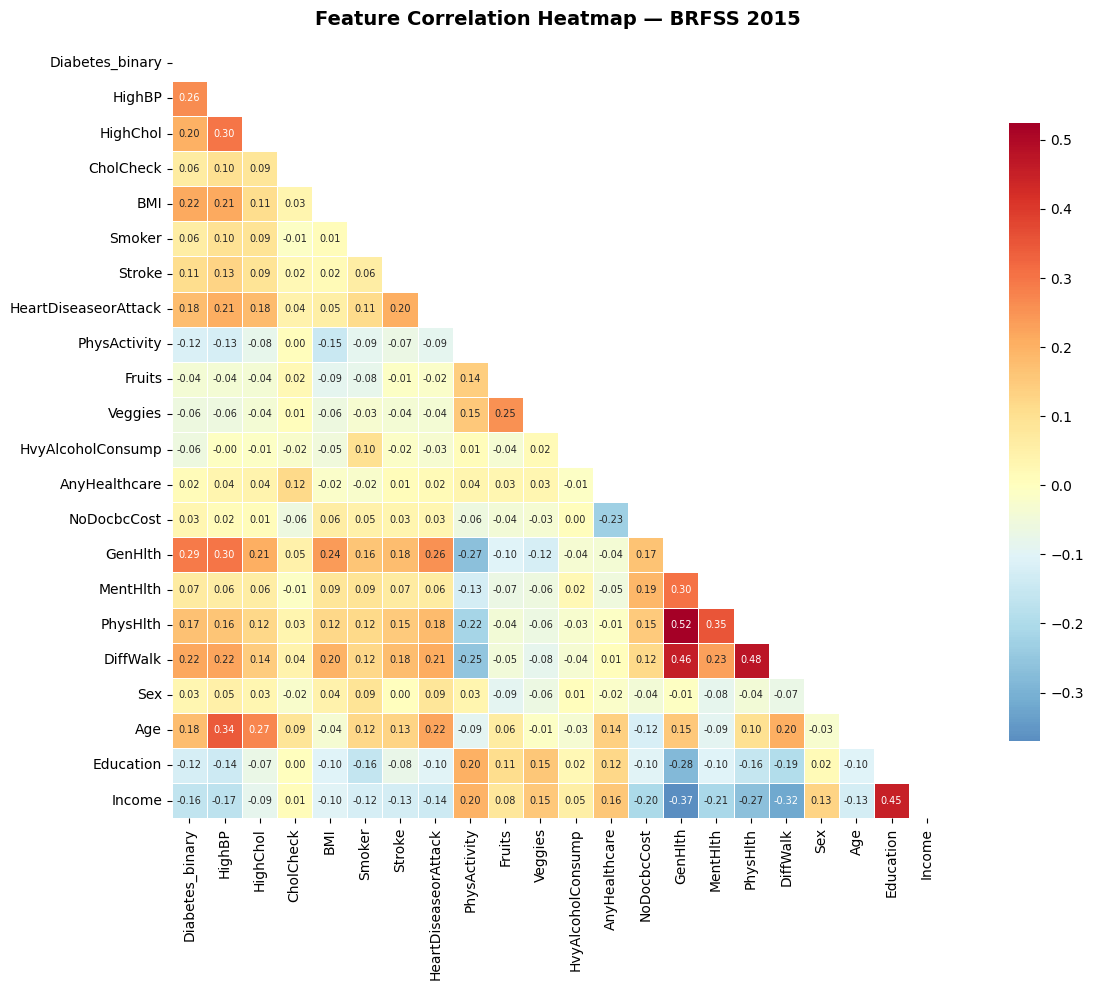

In [41]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(14, 10))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, ax=ax, annot_kws={'size': 7},
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap — BRFSS 2015', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

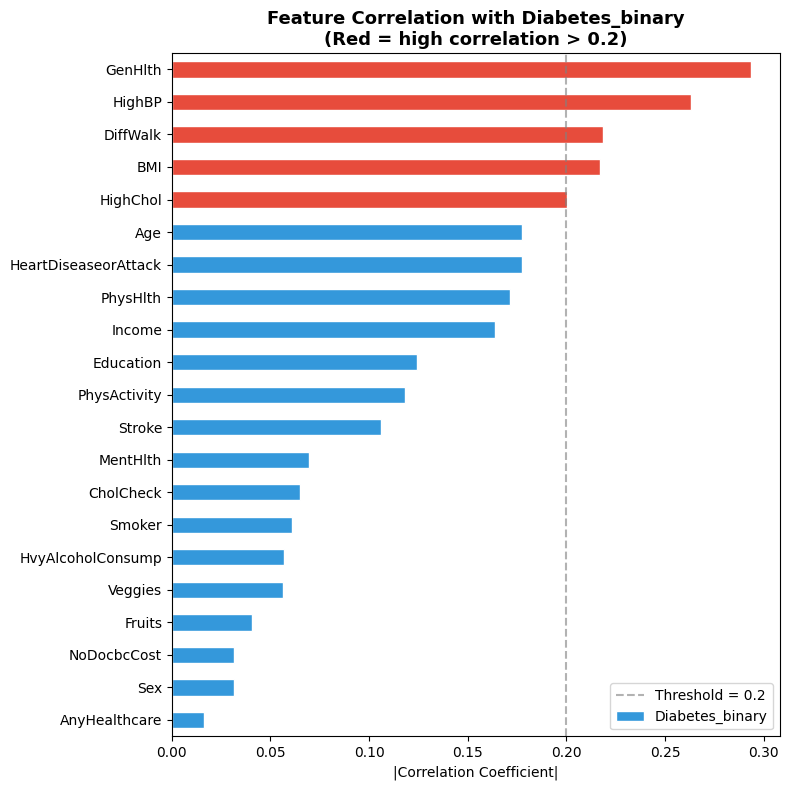

In [42]:
# Feature correlation with target (sorted)
target_corr = df.corr()['Diabetes_binary'].drop('Diabetes_binary').abs().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 8))
colors = ['#e74c3c' if v > 0.2 else '#3498db' for v in target_corr.values]
target_corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Feature Correlation with Diabetes_binary\n(Red = high correlation > 0.2)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('|Correlation Coefficient|')
ax.axvline(x=0.2, color='gray', linestyle='--', alpha=0.6, label='Threshold = 0.2')
ax.legend()
plt.tight_layout()
plt.savefig('target_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 🔧 Preprocessing

Following Rahman et al. (2025):
- No mean imputation needed (BRFSS has no missing values)
- SMOTE for class imbalance (consistent with Rahman et al. random oversampling strategy; SMOTE is preferred here as it generates synthetic samples rather than duplicating, reducing overfitting risk)
- 70/30 train-test split with stratification

In [43]:
# Feature/target split
TARGET = 'Diabetes_binary'
FEATURE_NAMES = [c for c in df.columns if c != TARGET]

X = df[FEATURE_NAMES].values
y = df[TARGET].values.astype(int)

print(f"Features: {len(FEATURE_NAMES)}")
print(f"Feature names: {FEATURE_NAMES}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

Features: 21
Feature names: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']
X shape: (253680, 21), y shape: (253680,)


In [44]:
# 70/30 stratified split (Rahman et al. use 70:30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

print(f"Train size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}")
print(f"Train class distribution — 0: {sum(y_train==0):,} | 1: {sum(y_train==1):,}")
print(f"Test class distribution  — 0: {sum(y_test==0):,} | 1: {sum(y_test==1):,}")

Train size: 177,576 | Test size: 76,104
Train class distribution — 0: 152,834 | 1: 24,742
Test class distribution  — 0: 65,500 | 1: 10,604


In [45]:
# Apply SMOTE only on training data (NEVER on test data — data leakage!)
print("Applying SMOTE to training set...")
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"Train size: {X_train_res.shape[0]:,}")
print(f"Class 0: {sum(y_train_res==0):,} | Class 1: {sum(y_train_res==1):,}")
print("✅ Classes balanced")

Applying SMOTE to training set...

After SMOTE:
Train size: 305,668
Class 0: 152,834 | Class 1: 152,834
✅ Classes balanced


In [46]:
# Feature scaling (important for LIME and PDP visualizations)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# Also keep unscaled versions — LightGBM doesn't require scaling but XAI tools benefit
print("✅ Features scaled (StandardScaler fitted on SMOTE-resampled training data)")

✅ Features scaled (StandardScaler fitted on SMOTE-resampled training data)


## 4. 🌱 Baseline LightGBM (All 21 Features)

We first establish a baseline using all features before applying feature selection, mirroring the approach of Rahman et al. (2025) who compare baseline vs. selected-feature performance.

In [47]:
# ── Baseline LightGBM Parameters ──────────────────────────────────────────
# Based on Rahman et al. (2025) and LGBM documentation best practices
lgbm_baseline = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=50,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    class_weight='balanced',       # Extra safeguard for imbalance
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

import time
start = time.time()
lgbm_baseline.fit(
    X_train_scaled, y_train_res,
    eval_set=[(X_test_scaled, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)]
)
baseline_time = time.time() - start
print(f"✅ Baseline LightGBM trained in {baseline_time:.2f}s")

# Baseline evaluation
y_pred_baseline = lgbm_baseline.predict(X_test_scaled)
y_prob_baseline = lgbm_baseline.predict_proba(X_test_scaled)[:, 1]

print("\n── Baseline Performance (all 21 features) ──")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_baseline):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_baseline):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_baseline):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob_baseline):.4f}")

✅ Baseline LightGBM trained in 21.54s

── Baseline Performance (all 21 features) ──
Accuracy:  0.8648
Precision: 0.5387
Recall:    0.2055
F1-Score:  0.2975
AUC-ROC:   0.8261


## 5. 🎯 Feature Importance & Selection

We use LightGBM's built-in feature importance (gain-based) to identify the most predictive features, consistent with Rahman et al. (2025) who use SHAP + Boruta. Here we use SHAP-based selection as it is more interpretable.

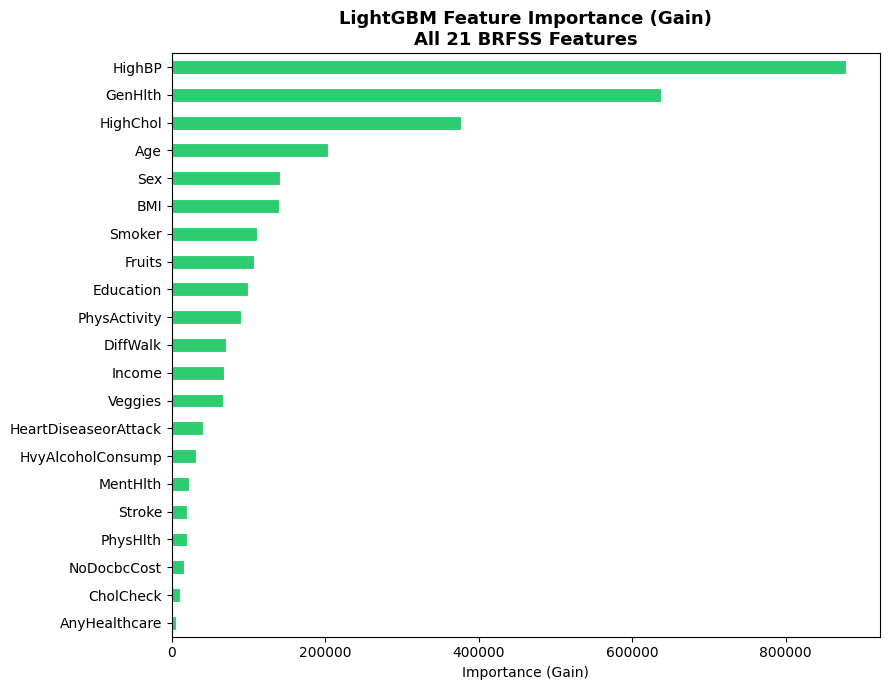

In [48]:
# LightGBM native feature importance (gain)
fi_gain = pd.Series(
    lgbm_baseline.booster_.feature_importance(importance_type='gain'),
    index=FEATURE_NAMES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
fi_gain.plot(kind='barh', ax=ax, color='#2ecc71', edgecolor='white', linewidth=0.8)
ax.set_title('LightGBM Feature Importance (Gain)\nAll 21 BRFSS Features',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance (Gain)')
plt.tight_layout()
plt.savefig('feature_importance_gain.png', dpi=150, bbox_inches='tight')
plt.show()

In [49]:
# SHAP-based feature importance for selection
print("Computing SHAP values for feature selection (this may take ~1-2 min)...")
explainer_baseline = shap.TreeExplainer(lgbm_baseline)

# Use a sample for speed (5000 from test set)
shap_sample_idx = np.random.choice(len(X_test_scaled), size=min(5000, len(X_test_scaled)), replace=False)
X_shap_sample = X_test_scaled[shap_sample_idx]

shap_values_baseline = explainer_baseline.shap_values(X_shap_sample)

# Mean absolute SHAP values per feature
if isinstance(shap_values_baseline, list):
    shap_vals = shap_values_baseline[1]   # class 1 (diabetic)
else:
    shap_vals = shap_values_baseline

mean_shap = pd.Series(
    np.abs(shap_vals).mean(axis=0),
    index=FEATURE_NAMES
).sort_values(ascending=False)

print("\nTop 10 features by mean |SHAP| value:")
print(mean_shap.head(10).to_string())

# Select top features (threshold: mean SHAP > mean of all mean SHAPs)
shap_threshold = mean_shap.mean()
selected_features = mean_shap[mean_shap >= shap_threshold].index.tolist()
print(f"\n✅ Selected {len(selected_features)} features (SHAP >= {shap_threshold:.4f}):")
print(selected_features)

Computing SHAP values for feature selection (this may take ~1-2 min)...

Top 10 features by mean |SHAP| value:
HighBP          0.658598
GenHlth         0.614111
Age             0.402467
BMI             0.396058
HighChol        0.384182
Fruits          0.336021
Smoker          0.308747
Veggies         0.259375
Education       0.231626
PhysActivity    0.231131

✅ Selected 8 features (SHAP >= 0.2348):
['HighBP', 'GenHlth', 'Age', 'BMI', 'HighChol', 'Fruits', 'Smoker', 'Veggies']


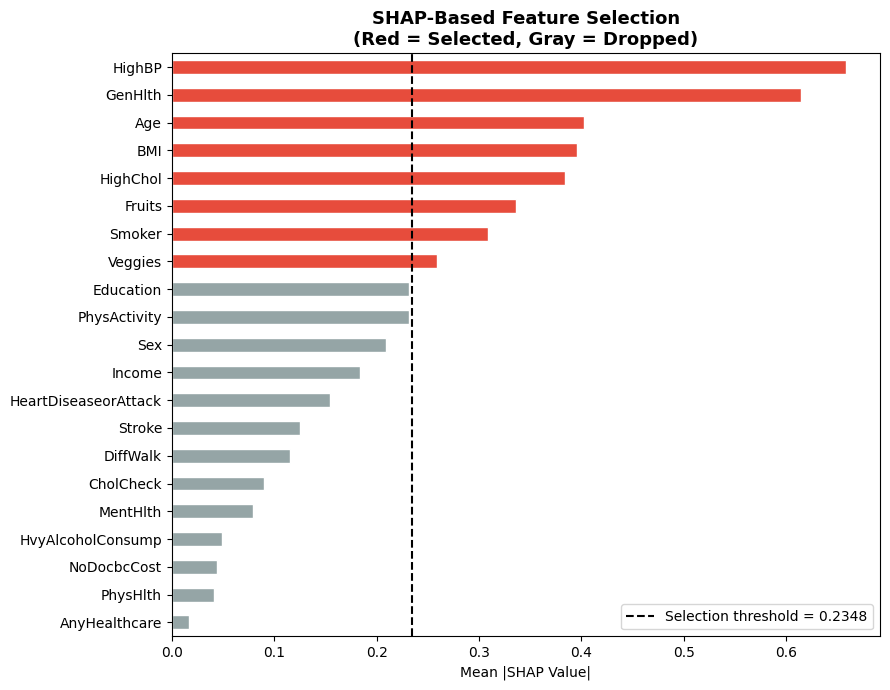

In [50]:
# Plot selected vs dropped features
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#e74c3c' if f in selected_features else '#95a5a6' for f in mean_shap.sort_values().index]
mean_shap.sort_values().plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(x=shap_threshold, color='black', linestyle='--', linewidth=1.5,
           label=f'Selection threshold = {shap_threshold:.4f}')
ax.set_title('SHAP-Based Feature Selection\n(Red = Selected, Gray = Dropped)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean |SHAP Value|')
ax.legend()
plt.tight_layout()
plt.savefig('shap_feature_selection.png', dpi=150, bbox_inches='tight')
plt.show()

In [51]:
# Create datasets with selected features
selected_idx = [FEATURE_NAMES.index(f) for f in selected_features]

X_train_sel = X_train_scaled[:, selected_idx]
X_test_sel  = X_test_scaled[:, selected_idx]

print(f"Original feature count:  {len(FEATURE_NAMES)}")
print(f"Selected feature count:  {len(selected_features)}")
print(f"Feature reduction: {(1 - len(selected_features)/len(FEATURE_NAMES))*100:.1f}%")

Original feature count:  21
Selected feature count:  8
Feature reduction: 61.9%


## 6. 🚀 Final LightGBM + Threshold Tuning

Since this is a medical task, **Recall (sensitivity) is the primary metric** — failing to detect a diabetic patient (False Negative) is more costly than a false alarm. We tune the classification threshold to maximize recall while maintaining acceptable precision.

In [52]:
# ── Final LightGBM on selected features ───────────────────────────────────
lgbm_final = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=7,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.85,
    subsample_freq=1,
    colsample_bytree=0.85,
    reg_alpha=0.05,
    reg_lambda=0.05,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

start = time.time()
lgbm_final.fit(
    X_train_sel, y_train_res,
    eval_set=[(X_test_sel, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)]
)
final_time = time.time() - start
print(f"✅ Final LightGBM trained in {final_time:.2f}s")
print(f"   Speedup vs baseline: {(baseline_time - final_time) / baseline_time * 100:.1f}% faster")

✅ Final LightGBM trained in 16.31s
   Speedup vs baseline: 24.3% faster


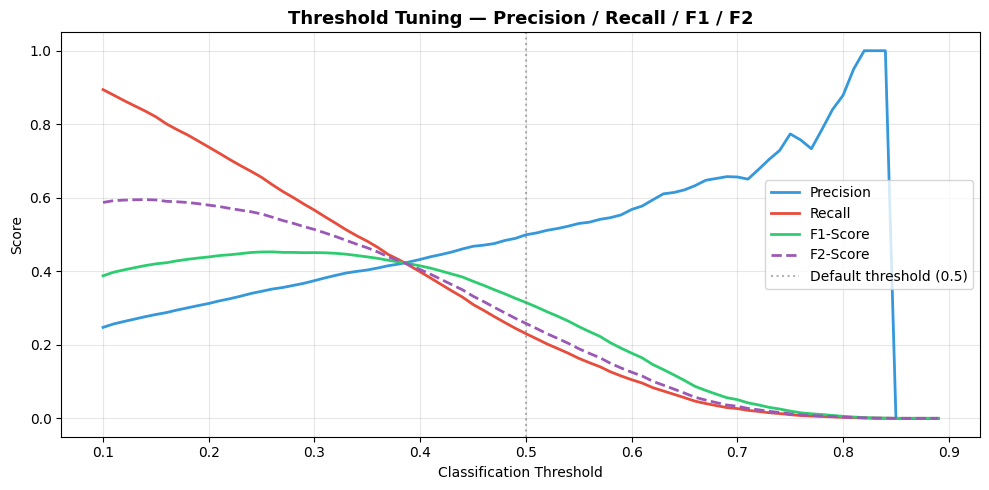


Best threshold by F2-score: 0.14
  At this threshold → Precision: 0.2766, Recall: 0.8356, F2: 0.5951


In [53]:
# Threshold tuning for optimal recall-precision balance
y_prob_final = lgbm_final.predict_proba(X_test_sel)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
results = []
for t in thresholds:
    y_pred_t = (y_prob_final >= t).astype(int)
    results.append({
        'threshold': t,
        'accuracy':  accuracy_score(y_test, y_pred_t),
        'precision': precision_score(y_test, y_pred_t, zero_division=0),
        'recall':    recall_score(y_test, y_pred_t, zero_division=0),
        'f1':        f1_score(y_test, y_pred_t, zero_division=0),
        'f2':        fbeta_score(y_test, y_pred_t, beta=2, zero_division=0)  # F-beta(2) weights recall higher
    })

results_df = pd.DataFrame(results)

# Plot threshold curves
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(results_df['threshold'], results_df['precision'], label='Precision', color='#3498db', linewidth=2)
ax.plot(results_df['threshold'], results_df['recall'],    label='Recall',    color='#e74c3c', linewidth=2)
ax.plot(results_df['threshold'], results_df['f1'],        label='F1-Score',  color='#2ecc71', linewidth=2)
ax.plot(results_df['threshold'], results_df['f2'],        label='F2-Score',  color='#9b59b6', linewidth=2, linestyle='--')
ax.axvline(x=0.5, color='gray', linestyle=':', alpha=0.6, label='Default threshold (0.5)')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Tuning — Precision / Recall / F1 / F2', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

# Best threshold by F2-score (weights recall 2x over precision)
best_row = results_df.loc[results_df['f2'].idxmax()]
BEST_THRESHOLD = best_row['threshold']
print(f"\nBest threshold by F2-score: {BEST_THRESHOLD:.2f}")
print(f"  At this threshold → Precision: {best_row['precision']:.4f}, Recall: {best_row['recall']:.4f}, F2: {best_row['f2']:.4f}")

## 7. 📈 Full Evaluation

In [54]:
# Final predictions with tuned threshold
y_pred_final = (y_prob_final >= BEST_THRESHOLD).astype(int)

# Compute all metrics
acc   = accuracy_score(y_test, y_pred_final)
prec  = precision_score(y_test, y_pred_final)
rec   = recall_score(y_test, y_pred_final)
f1    = f1_score(y_test, y_pred_final)
f2    = fbeta_score(y_test, y_pred_final, beta=2) # Use fbeta_score for f2
auc   = roc_auc_score(y_test, y_prob_final)
ap    = average_precision_score(y_test, y_prob_final)

print("═" * 50)
print("   FINAL LIGHTGBM EVALUATION RESULTS")
print("═" * 50)
print(f"  Threshold used    : {BEST_THRESHOLD:.2f}")
print(f"  Features used     : {len(selected_features)} / {len(FEATURE_NAMES)}")
print("─" * 50)
print(f"  Accuracy          : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision         : {prec:.4f}")
print(f"  Recall (Sensitivity): {rec:.4f}")
print(f"  F1-Score          : {f1:.4f}")
print(f"  F2-Score          : {f2:.4f}")
print(f"  AUC-ROC           : {auc:.4f}")
print(f"  Avg Precision     : {ap:.4f}")
print("═" * 50)

print("\n" + classification_report(y_test, y_pred_final, target_names=['No Diabetes', 'Diabetes']))

══════════════════════════════════════════════════
   FINAL LIGHTGBM EVALUATION RESULTS
══════════════════════════════════════════════════
  Threshold used    : 0.14
  Features used     : 8 / 21
──────────────────────────────────────────────────
  Accuracy          : 0.6726  (67.26%)
  Precision         : 0.2766
  Recall (Sensitivity): 0.8356
  F1-Score          : 0.4156
  F2-Score          : 0.5951
  AUC-ROC           : 0.8163
  Avg Precision     : 0.4054
══════════════════════════════════════════════════

              precision    recall  f1-score   support

 No Diabetes       0.96      0.65      0.77     65500
    Diabetes       0.28      0.84      0.42     10604

    accuracy                           0.67     76104
   macro avg       0.62      0.74      0.59     76104
weighted avg       0.87      0.67      0.72     76104



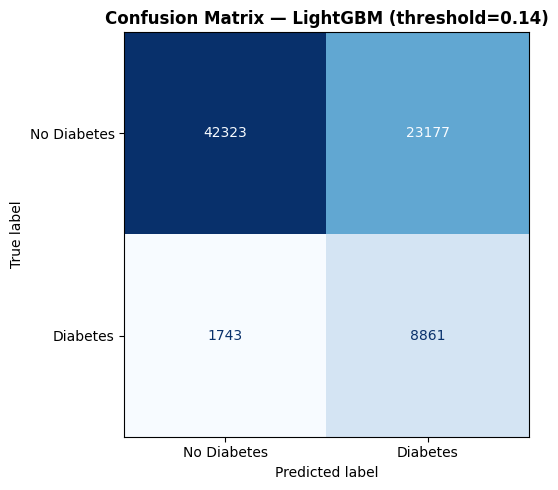

True Positives (TP): 8,861  — Diabetic correctly identified
True Negatives (TN): 42,323  — Non-diabetic correctly identified
False Positives (FP): 23,177 — Non-diabetic classified as diabetic
False Negatives (FN): 1,743 — Diabetic MISSED (most critical error in healthcare)


In [55]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — LightGBM (threshold={BEST_THRESHOLD:.2f})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives (TP): {tp:,}  — Diabetic correctly identified")
print(f"True Negatives (TN): {tn:,}  — Non-diabetic correctly identified")
print(f"False Positives (FP): {fp:,} — Non-diabetic classified as diabetic")
print(f"False Negatives (FN): {fn:,} — Diabetic MISSED (most critical error in healthcare)")

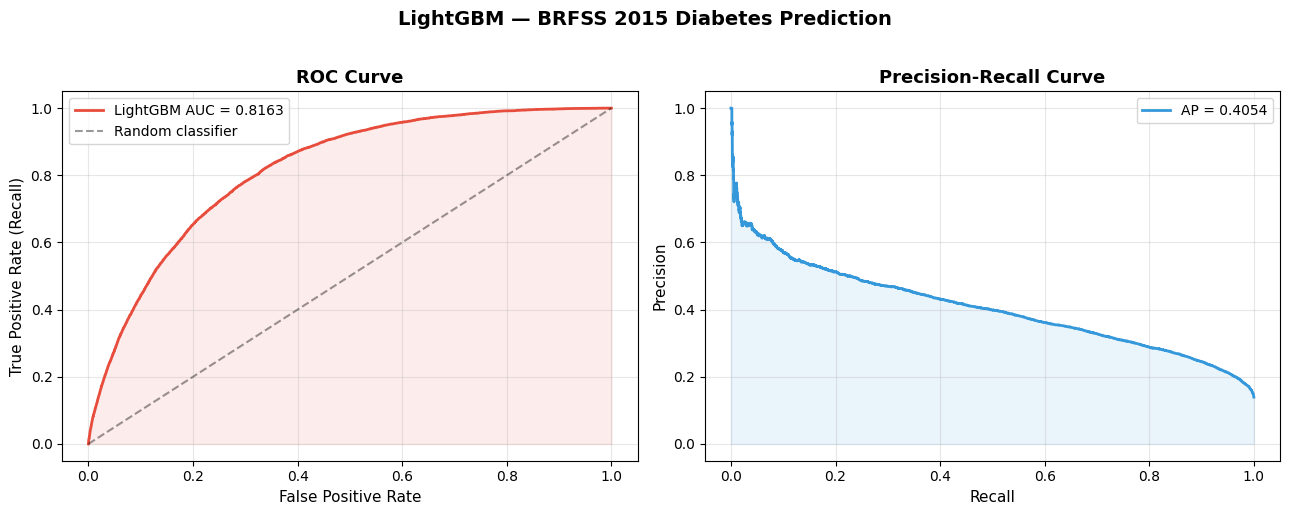

In [56]:
# ROC Curve + Precision-Recall Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_final)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob_final)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
axes[0].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'LightGBM AUC = {auc:.4f}')
axes[0].plot([0,1],[0,1], 'k--', alpha=0.4, label='Random classifier')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate (Recall)', fontsize=11)
axes[0].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Precision-Recall
axes[1].plot(rec_curve, prec_curve, color='#3498db', lw=2, label=f'AP = {ap:.4f}')
axes[1].fill_between(rec_curve, prec_curve, alpha=0.1, color='#3498db')
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.suptitle('LightGBM — BRFSS 2015 Diabetes Prediction', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# 5-fold Cross-Validation on full training data (Rahman et al. use 5-fold)
print("Running 5-fold cross-validation...")
cv_model = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    num_leaves=50, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_auc = cross_val_score(cv_model, X_train_scaled, y_train_res,
                         cv=skf, scoring='roc_auc', n_jobs=-1)
cv_f1  = cross_val_score(cv_model, X_train_scaled, y_train_res,
                         cv=skf, scoring='f1', n_jobs=-1)

print(f"\n5-Fold Cross-Validation Results:")
print(f"  AUC-ROC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
print(f"  F1:      {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print(f"  (Low std = stable model ✅)")

Running 5-fold cross-validation...

5-Fold Cross-Validation Results:
  AUC-ROC: 0.9714 ± 0.0003
  F1:      0.9147 ± 0.0012
  (Low std = stable model ✅)


In [33]:
# Comparison table: Baseline vs Final (matching Rahman et al. Table 9 style)
comparison = pd.DataFrame({
    'Model': ['LightGBM Baseline (21 features)', f'LightGBM Final ({len(selected_features)} features)'],
    'Accuracy': [
        accuracy_score(y_test, lgbm_baseline.predict(X_test_scaled)),
        acc
    ],
    'Precision': [
        precision_score(y_test, lgbm_baseline.predict(X_test_scaled)),
        prec
    ],
    'Recall': [
        recall_score(y_test, lgbm_baseline.predict(X_test_scaled)),
        rec
    ],
    'F1-Score': [
        f1_score(y_test, lgbm_baseline.predict(X_test_scaled)),
        f1
    ],
    'AUC-ROC': [
        roc_auc_score(y_test, lgbm_baseline.predict_proba(X_test_scaled)[:, 1]),
        auc
    ],
    'Training Time (s)': [round(baseline_time, 4), round(final_time, 4)]
})

print("\n── Model Comparison Table (similar to Rahman et al. 2025, Table 9) ──")
comparison.set_index('Model').style.background_gradient(cmap='Greens', subset=['Accuracy','Recall','F1-Score','AUC-ROC'])


── Model Comparison Table (similar to Rahman et al. 2025, Table 9) ──


,Accuracy,Precision,Recall,F1-Score,AUC-ROC,Training Time (s)
Model,,,,,,
LightGBM Baseline (21 features),0.864777,0.538690,0.205488,0.297495,0.826074,19.651300
LightGBM Final (8 features),0.672553,0.276578,0.835628,0.415600,0.816275,19.010300


## 8. 🔍 XAI Technique 1: SHAP Analysis

**SHAP (SHapley Additive exPlanations)** — Uses game theory to assign each feature a contribution score for each prediction. Provides both global (population-level) and local (patient-level) explanations.

> *Reference: Rahman et al. (2025) use SHAP analysis to validate feature importance and confirm clinical relevance of selected features.*

In [57]:
print("Computing SHAP values on final model (selected features)...")
explainer_final = shap.TreeExplainer(lgbm_final)

# Use a 3000-sample subset for readability
shap_n = min(3000, len(X_test_sel))
shap_idx = np.random.choice(len(X_test_sel), size=shap_n, replace=False)
X_shap = X_test_sel[shap_idx]

shap_values_final = explainer_final.shap_values(X_shap)

if isinstance(shap_values_final, list):
    sv = shap_values_final[1]
else:
    sv = shap_values_final

print(f"✅ SHAP values computed for {shap_n} samples")

Computing SHAP values on final model (selected features)...
✅ SHAP values computed for 3000 samples


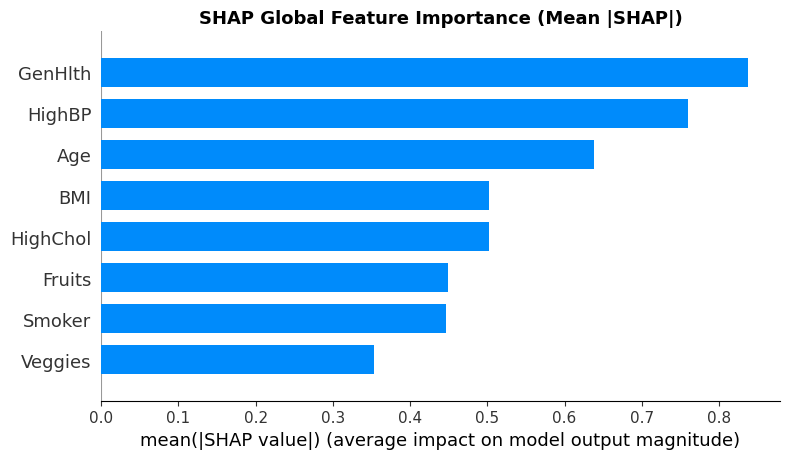

In [58]:
# XAI 1a: Global SHAP bar plot (mean absolute SHAP)
shap.summary_plot(
    sv, X_shap,
    feature_names=selected_features,
    plot_type='bar',
    show=False,
    max_display=len(selected_features)
)
plt.title('SHAP Global Feature Importance (Mean |SHAP|)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

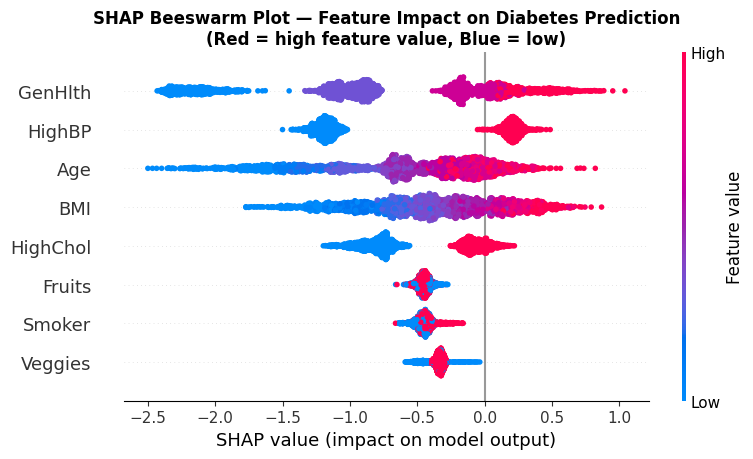


📌 Interpretation: Features on top have highest impact.
   Red points = high feature value → pushes prediction toward diabetes (right).
   Blue points = low feature value → pushes prediction away from diabetes (left).


In [59]:
# XAI 1b: SHAP beeswarm plot (direction + magnitude)
shap.summary_plot(
    sv, X_shap,
    feature_names=selected_features,
    plot_type='dot',
    show=False,
    max_display=len(selected_features)
)
plt.title('SHAP Beeswarm Plot — Feature Impact on Diabetes Prediction\n(Red = high feature value, Blue = low)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 Interpretation: Features on top have highest impact.")
print("   Red points = high feature value → pushes prediction toward diabetes (right).")
print("   Blue points = low feature value → pushes prediction away from diabetes (left).")

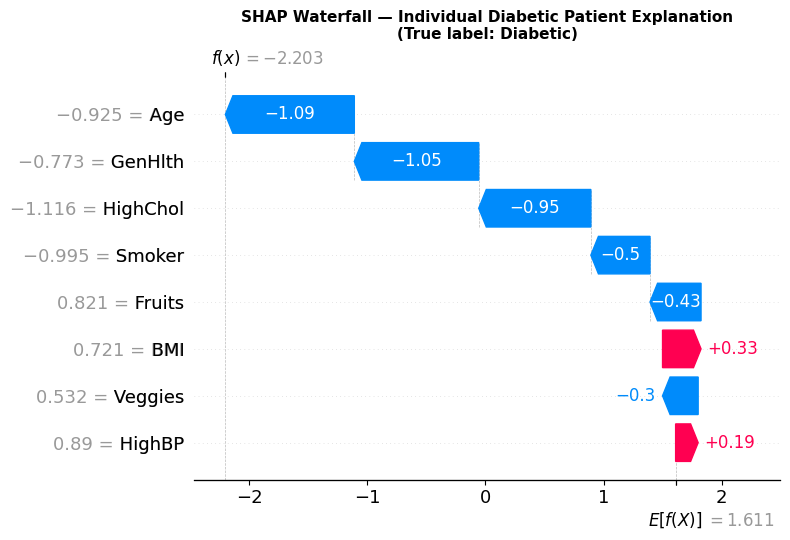


📌 This waterfall shows EXACTLY which features pushed this patient's prediction toward diabetes.


In [60]:
# XAI 1c: Local SHAP — Waterfall plot for a single DIABETIC patient
diabetic_indices = np.where(y_test[shap_idx] == 1)[0]
patient_idx = diabetic_indices[0]  # First diabetic patient in sample

expected_val = explainer_final.expected_value
if isinstance(expected_val, list): expected_val = expected_val[1]

shap_explanation = shap.Explanation(
    values=sv[patient_idx],
    base_values=expected_val,
    data=X_shap[patient_idx],
    feature_names=selected_features
)

shap.waterfall_plot(shap_explanation, show=False)
plt.title(f'SHAP Waterfall — Individual Diabetic Patient Explanation\n(True label: Diabetic)',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall_diabetic.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 This waterfall shows EXACTLY which features pushed this patient's prediction toward diabetes.")

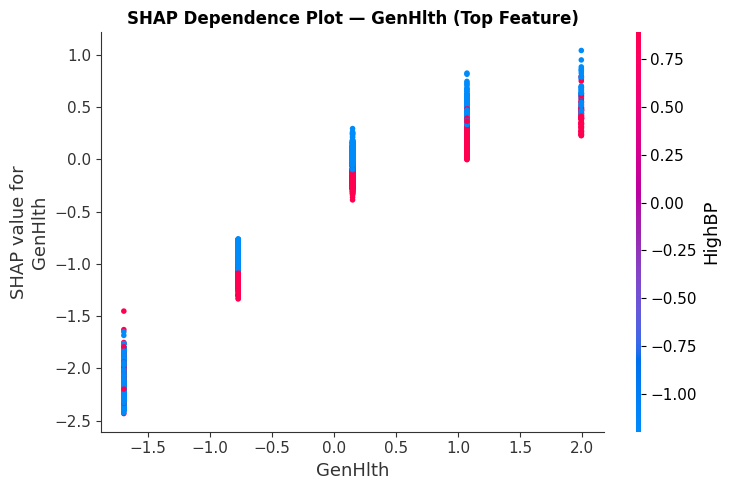


📌 Shows how GenHlth affects prediction, colored by the feature it interacts with most.


In [61]:
# XAI 1d: SHAP Force plot — most important feature interaction (dependence)
top_feature = pd.Series(np.abs(sv).mean(axis=0), index=selected_features).idxmax()
top_idx_in_selected = selected_features.index(top_feature)

shap.dependence_plot(
    top_idx_in_selected, sv, X_shap,
    feature_names=selected_features,
    interaction_index='auto',
    show=False
)
plt.title(f'SHAP Dependence Plot — {top_feature} (Top Feature)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n📌 Shows how {top_feature} affects prediction, colored by the feature it interacts with most.")

## 9. 🔍 XAI Technique 2: LIME (Local Interpretable Model-agnostic Explanations)

**LIME** explains individual predictions by locally approximating the complex model with a simpler interpretable model. Unlike SHAP, LIME is model-agnostic.

> *Reference: Kulkarni et al. (JETIR 2025) propose LIME for patient-specific explanations. LIME transforms abstract risk scores into concrete clinical narratives.*

In [62]:
# LIME explainer setup
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_sel,
    feature_names=selected_features,
    class_names=['No Diabetes', 'Diabetes'],
    mode='classification',
    discretize_continuous=True,
    random_state=RANDOM_STATE
)
print("✅ LIME explainer initialized")

✅ LIME explainer initialized


Patient predicted probability: No Diabetes=0.937, Diabetes=0.063
True label: Diabetic (1)


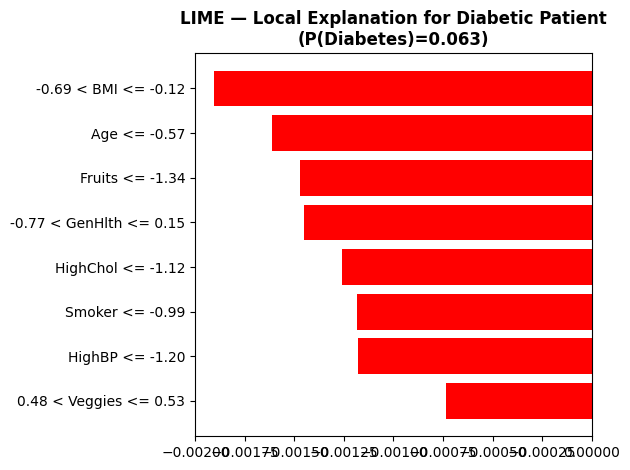

In [63]:
# LIME explanation for a DIABETIC patient
diabetic_test_idx = np.where(y_test == 1)[0][0]
patient_diabetic = X_test_sel[diabetic_test_idx]

lime_exp_diabetic = lime_explainer.explain_instance(
    data_row=patient_diabetic,
    predict_fn=lgbm_final.predict_proba,
    num_features=len(selected_features),
    num_samples=3000
)

prob_diabetic = lgbm_final.predict_proba([patient_diabetic])[0]
print(f"Patient predicted probability: No Diabetes={prob_diabetic[0]:.3f}, Diabetes={prob_diabetic[1]:.3f}")
print(f"True label: Diabetic (1)")

fig = lime_exp_diabetic.as_pyplot_figure()
plt.title(f'LIME — Local Explanation for Diabetic Patient\n(P(Diabetes)={prob_diabetic[1]:.3f})',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('lime_diabetic.png', dpi=150, bbox_inches='tight')
plt.show()

Patient predicted probability: No Diabetes=0.993, Diabetes=0.007
True label: No Diabetes (0)


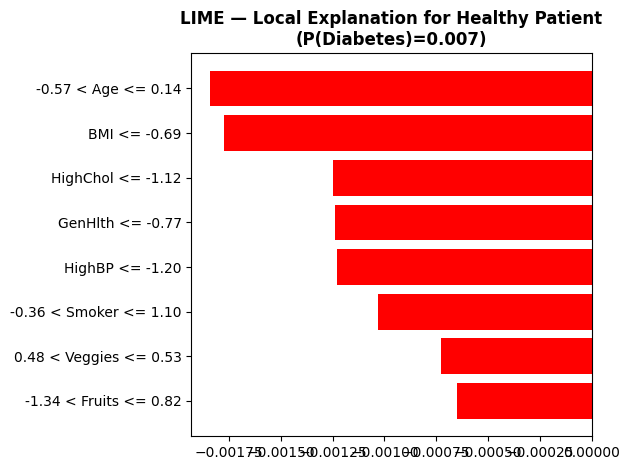


📌 LIME complements SHAP: while SHAP gives global picture, LIME explains individual predictions.
   Clinically valuable: a physician can see exactly why THIS patient was flagged.


In [64]:
# LIME explanation for a HEALTHY patient
healthy_test_idx = np.where(y_test == 0)[0][0]
patient_healthy = X_test_sel[healthy_test_idx]

lime_exp_healthy = lime_explainer.explain_instance(
    data_row=patient_healthy,
    predict_fn=lgbm_final.predict_proba,
    num_features=len(selected_features),
    num_samples=3000
)

prob_healthy = lgbm_final.predict_proba([patient_healthy])[0]
print(f"Patient predicted probability: No Diabetes={prob_healthy[0]:.3f}, Diabetes={prob_healthy[1]:.3f}")
print(f"True label: No Diabetes (0)")

fig = lime_exp_healthy.as_pyplot_figure()
plt.title(f'LIME — Local Explanation for Healthy Patient\n(P(Diabetes)={prob_healthy[1]:.3f})',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('lime_healthy.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 LIME complements SHAP: while SHAP gives global picture, LIME explains individual predictions.")
print("   Clinically valuable: a physician can see exactly why THIS patient was flagged.")

## 10. 🔍 XAI Technique 3: Permutation Importance

**Permutation Importance** measures how much model performance decreases when a feature's values are randomly shuffled. A large drop = the feature is important. This technique is model-agnostic and provides a reliable measure of actual predictive contribution.

Computing permutation importance (may take 1-2 min)...


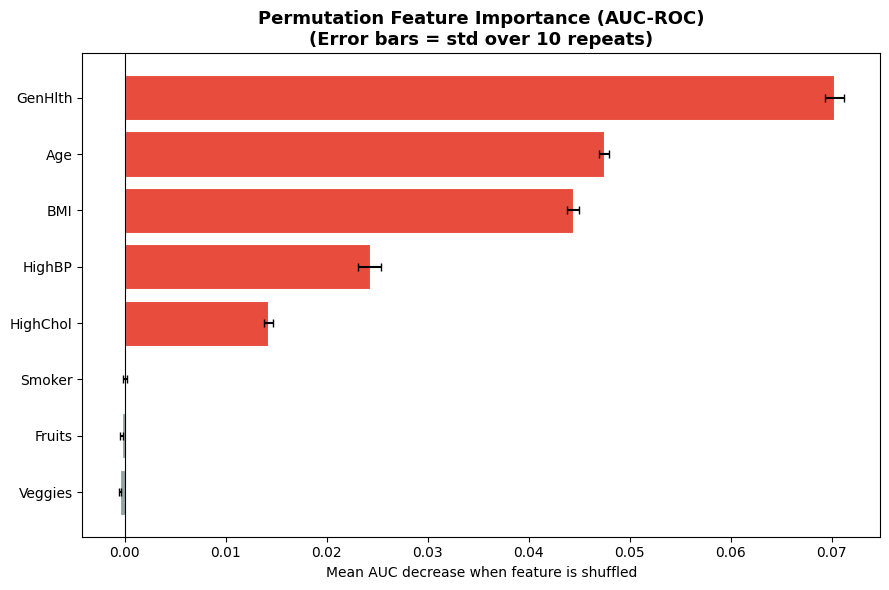


Top 5 most important features by permutation:
 Feature  Importance Mean  Importance Std
 GenHlth         0.070271        0.000932
     Age         0.047464        0.000497
     BMI         0.044404        0.000586
  HighBP         0.024262        0.001118
HighChol         0.014233        0.000473


In [65]:
# Permutation importance on test set
print("Computing permutation importance (may take 1-2 min)...")
perm_imp = permutation_importance(
    lgbm_final, X_test_sel, y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring='roc_auc',
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature':           selected_features,
    'Importance Mean':   perm_imp.importances_mean,
    'Importance Std':    perm_imp.importances_std
}).sort_values('Importance Mean', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(perm_df['Feature'], perm_df['Importance Mean'],
        xerr=perm_df['Importance Std'],
        color=['#e74c3c' if v > 0 else '#95a5a6' for v in perm_df['Importance Mean']],
        edgecolor='white', linewidth=0.8, capsize=3)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Permutation Feature Importance (AUC-ROC)\n(Error bars = std over 10 repeats)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean AUC decrease when feature is shuffled')
plt.tight_layout()
plt.savefig('permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 most important features by permutation:")
print(perm_df.sort_values('Importance Mean', ascending=False).head(5).to_string(index=False))

## 11. 🔍 XAI Technique 4: Partial Dependence Plots (PDP)

**PDPs** show the marginal effect of one or two features on the predicted outcome, averaging out all other features. They reveal the relationship shape: linear, monotonic, or non-linear.

In [74]:
from sklearn.base import BaseEstimator, RegressorMixin # Changed to RegressorMixin

# Wrapper to make predict method return P(class=1) for PDP
class ProbWrapper(BaseEstimator, RegressorMixin): # Changed ClassifierMixin to RegressorMixin
    def __init__(self, estimator):
        self.estimator = estimator
        # self.classes_ = np.array([0, 1]) # Removed classes_ attribute

    def fit(self, X, y=None):
        # The wrapped estimator is already fitted
        return self

    def predict_proba(self, X):
        # Keep predict_proba for compatibility if other parts of sklearn need it
        return self.estimator.predict_proba(X)

    def predict(self, X):
        # For PDP, we want 'predict' to return the probability of the positive class
        return self.estimator.predict_proba(X)[:, 1]


# PDP for top 4 features (by SHAP importance)
top4 = pd.Series(np.abs(sv).mean(axis=0), index=selected_features).nlargest(4).index.tolist()
top4_idx = [selected_features.index(f) for f in top4]

print(f"Computing PDP for top 4 features: {top4}")
print("(This may take ~1-2 min for large dataset...")

# Use a sample for PDP speed
pdp_sample_idx = np.random.choice(len(X_test_sel), size=min(3000, len(X_test_sel)), replace=False)
X_pdp = X_test_sel[pdp_sample_idx]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes_flat = axes.flatten()

# Create an instance of the wrapper
lgbm_pdp_wrapper = ProbWrapper(lgbm_final)
lgbm_pdp_wrapper.fit(X_pdp) # Explicitly call fit on the wrapper

for i, (feat_name, feat_idx) in enumerate(zip(top4, top4_idx)):
    PartialDependenceDisplay.from_estimator(
        lgbm_pdp_wrapper, # Use the wrapped estimator
        X_pdp,
        features=[feat_idx],
        feature_names=selected_features,
        ax=axes_flat[i],
        line_kw={'color': '#e74c3c', 'linewidth': 2},
        response_method='predict_proba' # Changed from 'predict' to 'predict_proba'
        # target is not needed as the wrapper's predict is specialized
    )
    axes_flat[i].set_title(f'PDP: {feat_name}', fontsize=11, fontweight='bold')
    axes_flat[i].set_ylabel('Partial Dependence (P(Diabetes))')
    axes_flat[i].grid(alpha=0.3)

plt.suptitle('Partial Dependence Plots — Top 4 Features\n(Shows marginal effect on P(Diabetes))',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pdp_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 PDPs reveal the relationship shape between each feature and diabetes risk.")
print("   Rising curves = higher feature value → higher diabetes risk.")

Computing PDP for top 4 features: ['GenHlth', 'HighBP', 'Age', 'BMI']
(This may take ~1-2 min for large dataset...


NotFittedError: This ProbWrapper instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

Computing 2D interaction PDP...


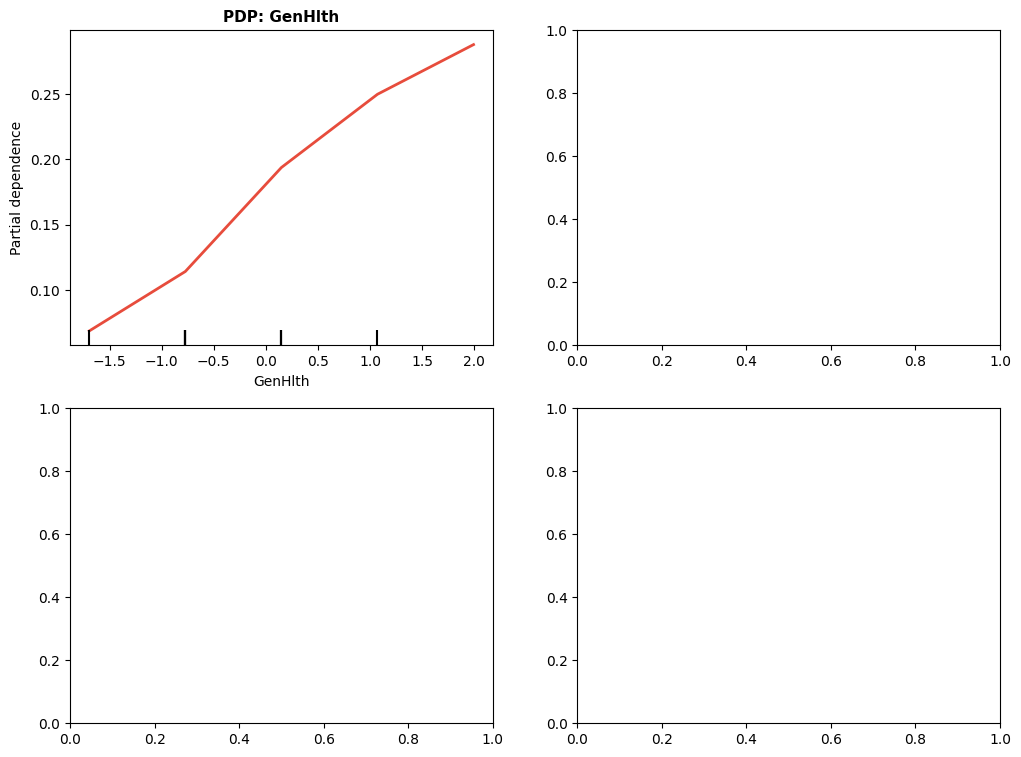

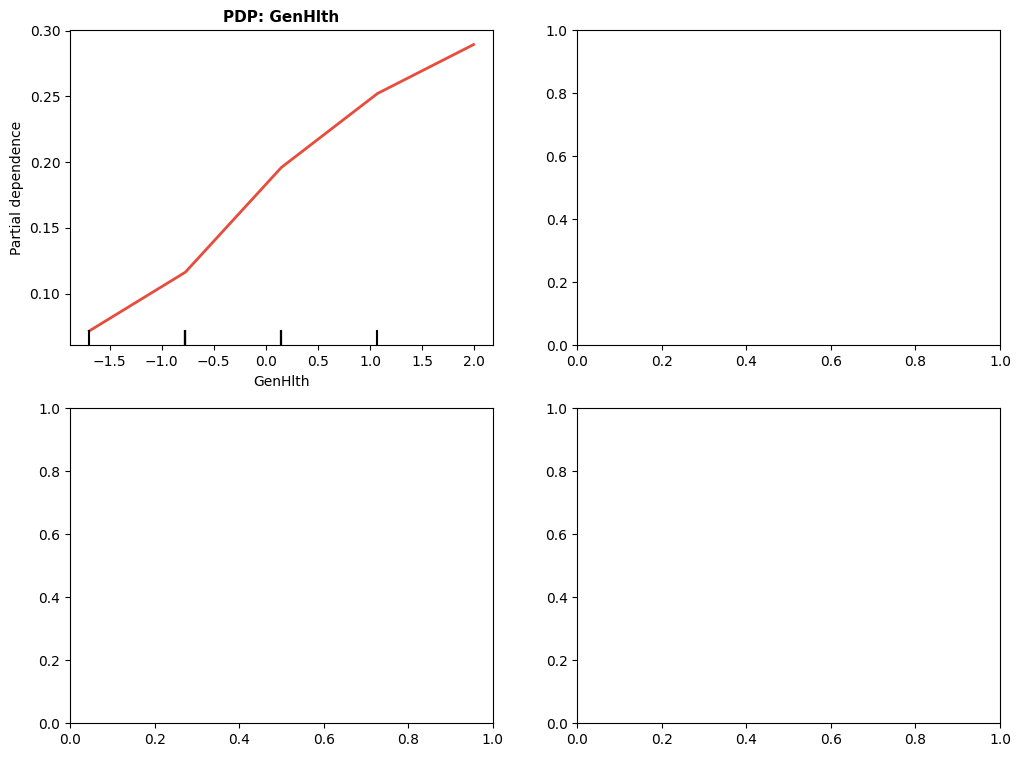

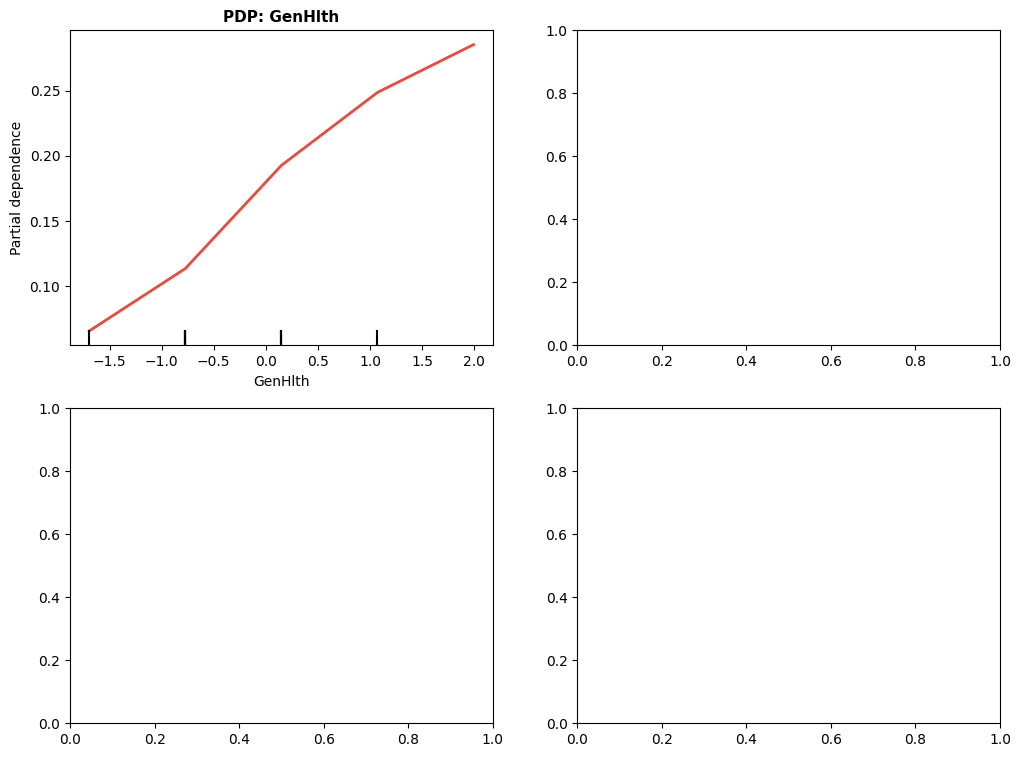

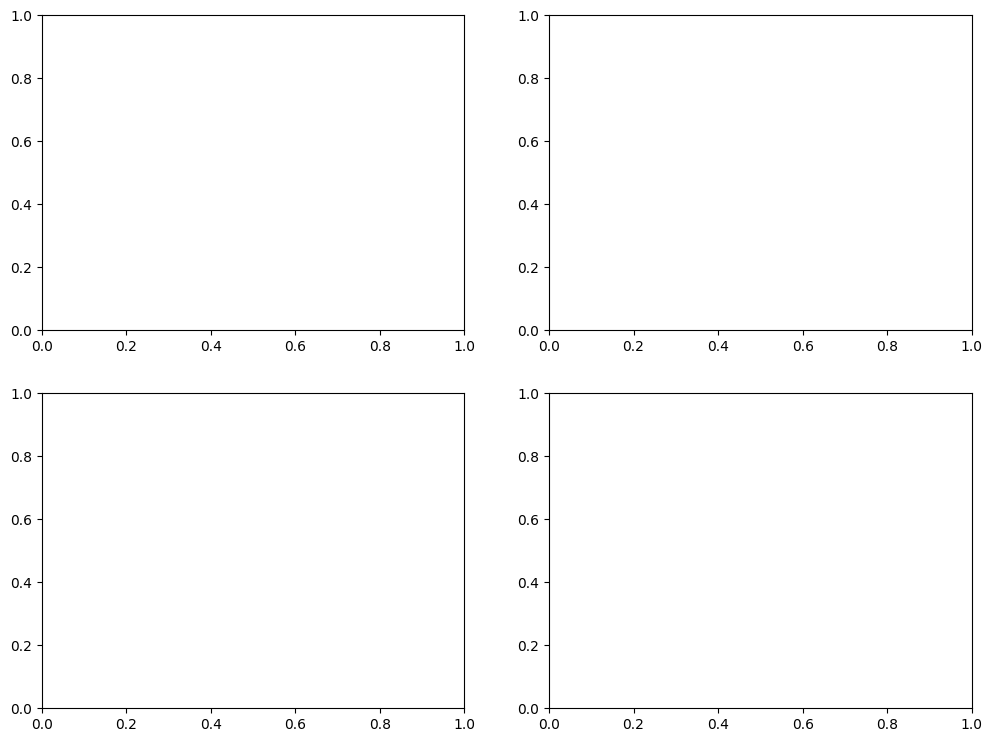

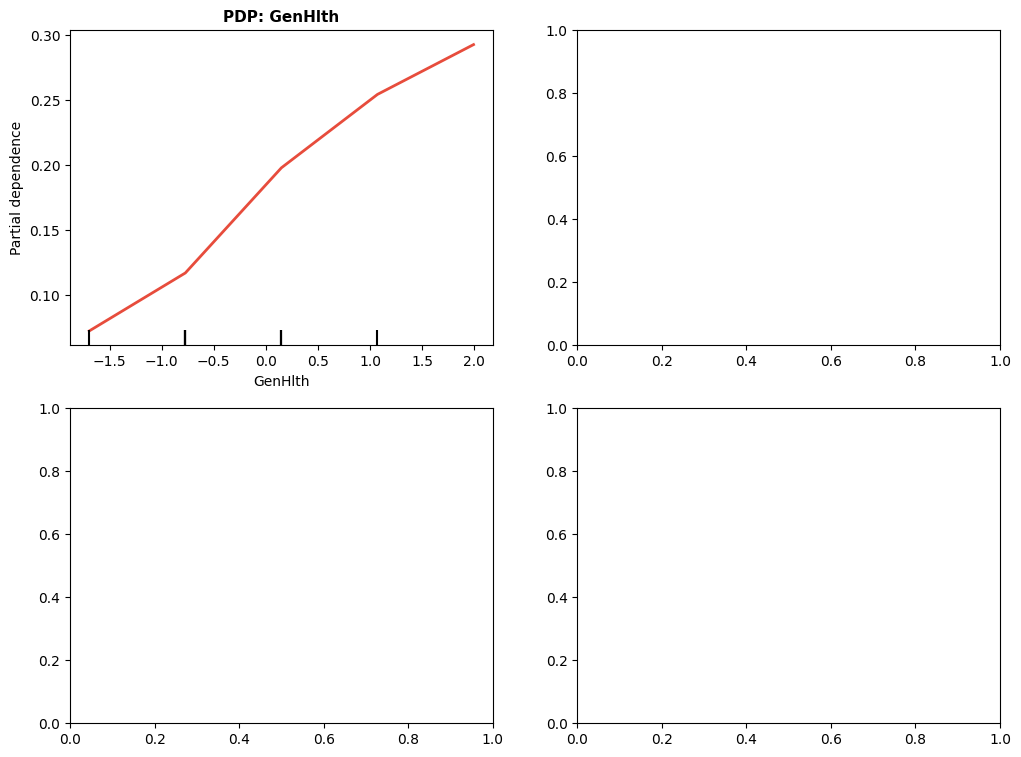

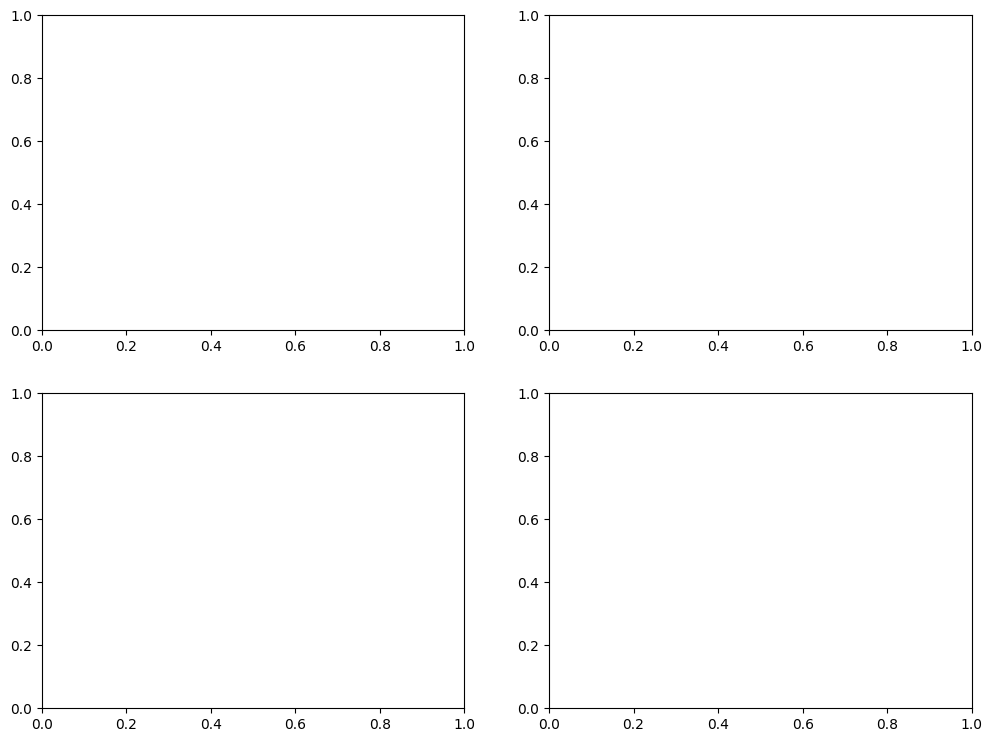

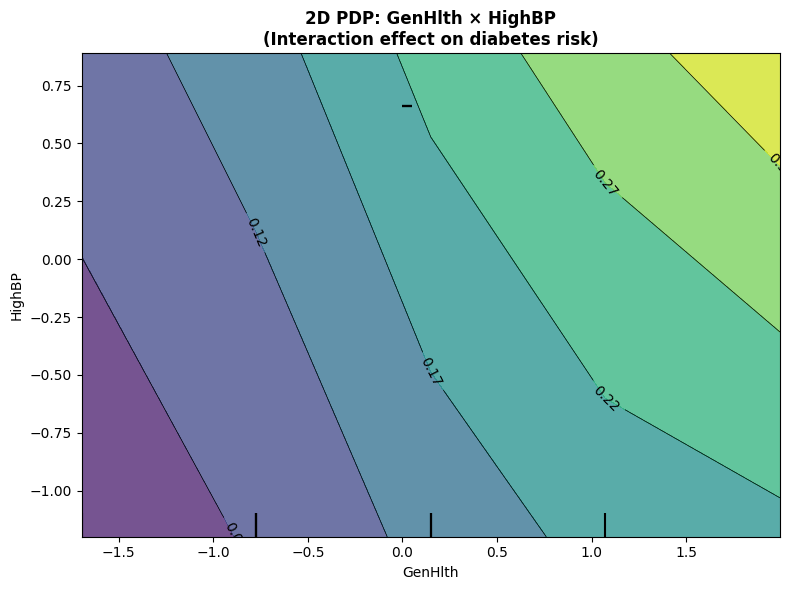

In [72]:
# 2D Interaction PDP (top 2 features)
print("Computing 2D interaction PDP...")
fig, ax = plt.subplots(figsize=(8, 6))

PartialDependenceDisplay.from_estimator(
    lgbm_final, X_pdp,
    features=[(top4_idx[0], top4_idx[1])],
    feature_names=selected_features,
    ax=ax,
    kind='average'
)
ax.set_title(f'2D PDP: {top4[0]} × {top4[1]}\n(Interaction effect on diabetes risk)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('pdp_2d.png', dpi=150, bbox_inches='tight')
plt.show()